# Baseline e Thompson Sampling contextual

O experimento compara a regra fixa conservadora `no_email` com Thompson Sampling Beta-Bernoulli. A política é ajustada no treino, selecionada na validação e medida uma única vez no teste. A avaliação principal executa o mesmo Thompson Sampling estocástico usado pela API.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path.cwd() / "src"))
from scripts.build_golden_set import build as build_golden_set
from scripts.run_experiment import fit_policy, run

from datathon.data import load_clean, stratified_split
from datathon.evaluation import sequential_replay
from datathon.policies import ThompsonSamplingPolicy

DATA_PATH = Path("data/raw/hillstrom.csv")
SUMMARY_PATH = Path("artifacts/experiment_summary.json")
FIGURES_PATH = Path("artifacts/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

summary = run(DATA_PATH, SUMMARY_PATH, seed=2026)
pd.DataFrame([summary["rows"]])

,total,train,validation,test
0,64000,38399,12799,12802


## Resultado final

O baseline obrigatório é `no_email`. A melhor ação fixa global é mostrada como referência adicional. Os intervalos de 95% abaixo usam as contribuições IPS por linha e devem ser interpretados como aproximações descritivas.

In [2]:
comparison = pd.DataFrame(
    [
        {
            "policy": "baseline_no_email",
            "value_ips": summary["baseline_value_ips"],
            "ci_lower": summary["baseline_ci95"][0],
            "ci_upper": summary["baseline_ci95"][1],
        },
        {
            "policy": f"best_fixed_{summary['best_fixed_action']}",
            "value_ips": summary["best_fixed_value_ips"],
            "ci_lower": summary["best_fixed_ci95"][0],
            "ci_upper": summary["best_fixed_ci95"][1],
        },
        {
            "policy": "thompson_sampling",
            "value_ips": summary["thompson_replay_value_ips"],
            "ci_lower": summary["thompson_replay_ci95"][0],
            "ci_upper": summary["thompson_replay_ci95"][1],
        },
    ]
)
comparison["difference_vs_baseline"] = comparison["value_ips"] - summary["baseline_value_ips"]
display(
    comparison.style.format(
        {
            "value_ips": "{:.4%}",
            "ci_lower": "{:.4%}",
            "ci_upper": "{:.4%}",
            "difference_vs_baseline": "{:+.4%}",
        }
    )
)

print(f"Política escolhida na validação: {summary['selected_policy']}")
print(f"Lift de Thompson Sampling contra no_email: {summary['lift_replay']:+.6f}")
print(f"Diferença contra a melhor ação fixa: {summary['lift_replay_vs_best_fixed']:+.6f}")
print(f"Exploração observada: {summary['thompson_exploration_rate']:.2%}")

,policy,value_ips,ci_lower,ci_upper,difference_vs_baseline
0,baseline_no_email,0.7030%,0.4517%,0.9543%,+0.0000%
1,best_fixed_mens_email,1.4763%,1.1127%,1.8400%,+0.7733%
2,thompson_sampling,1.3826%,1.0306%,1.7346%,+0.6796%


Política escolhida na validação: thompson_sampling
Lift de Thompson Sampling contra no_email: +0.006796
Diferença contra a melhor ação fixa: -0.000937
Exploração observada: 18.47%


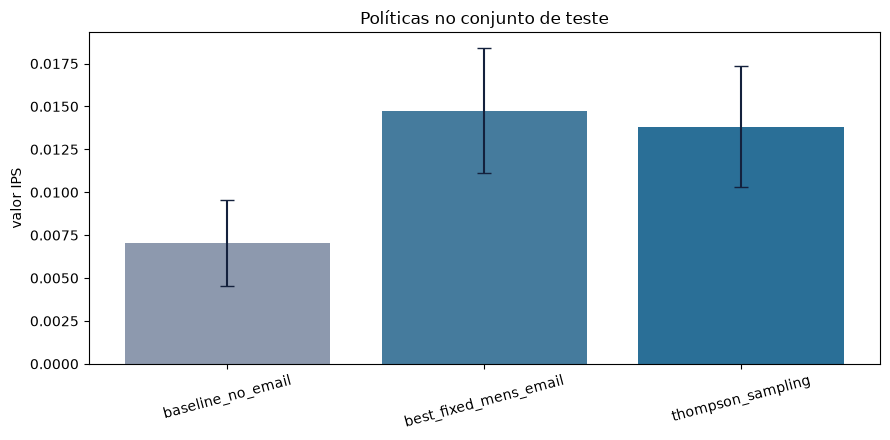

In [3]:
errors = [
    comparison["value_ips"] - comparison["ci_lower"],
    comparison["ci_upper"] - comparison["value_ips"],
]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(comparison["policy"], comparison["value_ips"], color=["#8d99ae", "#457b9d", "#2a6f97"])
ax.errorbar(
    comparison["policy"],
    comparison["value_ips"],
    yerr=errors,
    fmt="none",
    ecolor="#14213d",
    capsize=5,
)
ax.set_ylabel("valor IPS")
ax.set_title("Políticas no conjunto de teste")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIGURES_PATH / "policy_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Comportamento sequencial

No replay, a política recebe feedback somente quando sua ação coincide com a ação registrada. Esse procedimento preserva o caráter adaptativo e evita aprender com um resultado contrafactual inexistente.

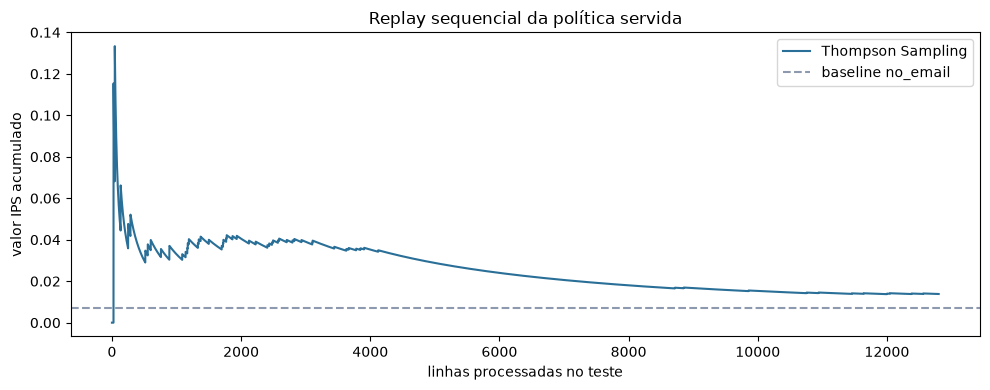

In [4]:
frame = load_clean(DATA_PATH)
train, _, test = stratified_split(frame, seed=2026)
replay_policy = ThompsonSamplingPolicy(seed=2026)
fit_policy(replay_policy, train)
replay = sequential_replay(test, replay_policy)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(replay.cumulative_values, color="#2a6f97", linewidth=1.5, label="Thompson Sampling")
ax.axhline(
    summary["baseline_value_ips"], color="#8d99ae", linestyle="--", label="baseline no_email"
)
ax.set_xlabel("linhas processadas no teste")
ax.set_ylabel("valor IPS acumulado")
ax.set_title("Replay sequencial da política servida")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_PATH / "sequential_replay.png", dpi=160, bbox_inches="tight")
plt.show()

## Golden Set

Os cinco casos usam segmentos presentes no snapshot treinado. A recomendação é produzida por `recommend`, o mesmo método chamado pela API. Uma escolha exploratória pode diferir da ação com maior média posterior e ainda fazer sentido para Thompson Sampling, desde que seja apresentada como aprendizado sob incerteza.

In [5]:
golden_rows = build_golden_set(Path("config/policy_snapshot.json"))
golden_table = pd.DataFrame(
    [
        {
            "case_id": row["case_id"],
            "segment": row["segment"],
            "recommended_action": row["recommended_action"],
            "exploitation_action": row["exploitation_action"],
            "exploration": row["exploration"],
            "decision_makes_sense": row["decision_makes_sense"],
            "rationale": row["rationale"],
        }
        for row in golden_rows
    ]
)
display(golden_table)

,case_id,segment,recommended_action,exploitation_action,exploration,decision_makes_sense,rationale
0,recent_mens_web,recent:mens,mens_email,mens_email,False,True,A decisão é coerente como aproveitamento: a aç...
1,recent_womens_multichannel,recent:womens,mens_email,mens_email,False,True,A decisão é coerente como aproveitamento: a aç...
2,middle_mixed_web,middle:mixed,mens_email,mens_email,False,True,A decisão é coerente como aproveitamento: a aç...
3,old_mens_phone,old:mens,mens_email,mens_email,False,True,A decisão é coerente como aproveitamento: a aç...
4,old_womens_web,old:womens,mens_email,mens_email,False,True,A decisão é coerente como aproveitamento: a aç...


## Interpretação e limites

Thompson Sampling supera o baseline conservador `no_email` no teste e atende ao critério acadêmico de ganho sobre o baseline. A melhor campanha fixa continua ligeiramente acima no replay atual, por isso o trabalho não afirma superioridade universal do bandit. O benefício da abordagem adaptativa é equilibrar aprendizado e aproveitamento por contexto, com atualização após feedback e rastreabilidade das decisões. Os intervalos se sobrepõem e a base é de varejo; qualquer uso financeiro exigiria validação própria, controles de risco e revisão humana.